# MsCua Calibration with Spotpy: Synthetic Example 2

This notebook will guide you through the use of the MSCUA calibration code in a case with two different observation time series that are being calibrated on. The overall process is very similar, but a few function names and argument structures are different.

In [1]:
from pathlib import Path
import sys
from typing import Union, Optional

import matplotlib.pyplot as plt
import numpy as np
import spotpy
import tqdm
import xarray

# calibration imports
root = r"C:\Users\CND571\PycharmProjects\calmd\src"
sys.path.append(root)

from calmd.algorithms import MsCua, SensitivityAnalysis
from calmd.database import MultiDimDb
from calmd.obj_funcs import nrmse_md, nse_md
from calmd.analyze import MsCuaAnalyzer, MsCuaAnalyzerDict


## Build a Dummy Model with Input Data & Observation Dataset

Our model will be a set of paired power-law and sine functions.

In [2]:
def exp_model(x, coef, exp):
    y1 = coef * x**(exp)
    y2 = 100 * exp * np.sin(coef * x)
    return {'y1': y1, 'y2': y2}

Create a set of random input values.

In [3]:
indata = np.random.uniform(1.0, 30.0, size=1000)

Run the model and add noise to the results to create our observation dataset.

In this case our target parameters are:
- coef = 0.03
- exp = 3.3

But for the actual calibration we will run the algorithm on 300 power functions at once, each with a different set of target/correct parameters.

In [4]:
outdata = exp_model(indata, 0.03, 3.3)

obsdata = dict()
for k, v in outdata.items():
    inrng = v.max() - v.min()
    noise = np.random.uniform(-inrng * 0.04, inrng * 0.04, size=v.shape)
    obsdata[k] = v + noise

Plot the observation data to inspect.

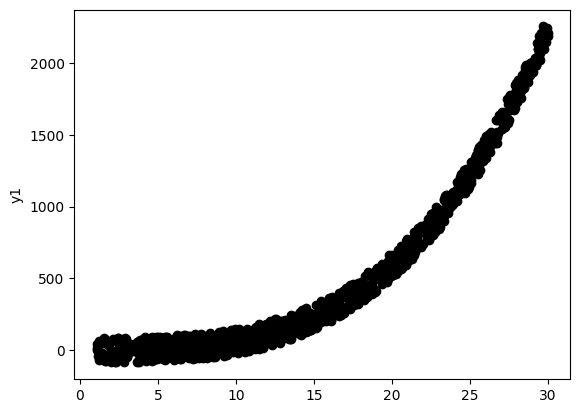

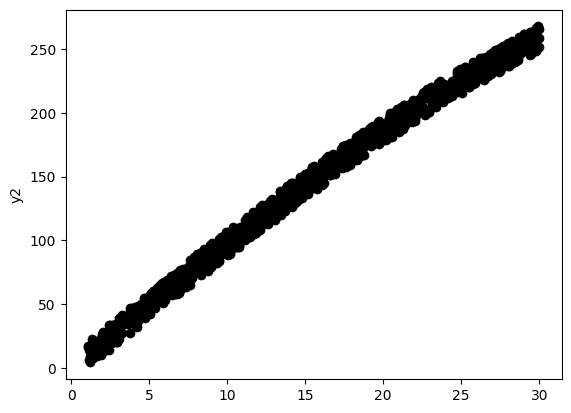

In [5]:
ax = plt.axes()
ax.plot(indata, obsdata['y1'], 'ko')
ax.set_ylabel('y1')
plt.show()

ax = plt.axes()
ax.plot(indata, obsdata['y2'], 'ko')
ax.set_ylabel('y2')
plt.show()

Ok, create the full multidimensional model and observation data.

In [6]:
num_models = 300
ex_idx = 250  # index used to plot the same model throughout this example.

In [7]:
target_coef = np.random.uniform(low=0.01, high=0.12, size=num_models)
target_exp = np.random.uniform(low=1.1, high=3.9, size=num_models)
mdindata = indata.reshape((indata.shape[0], 1))
outdata = exp_model(mdindata, target_coef, target_exp)

obsdata = dict()
for k, v in outdata.items():
    inrng = v.max(axis=0) - v.min(axis=0)
    noise = np.random.uniform(-0.04, 0.04, size=(v.shape[0], 1))
    mdnoise = noise * inrng
    obsdata[k] = v + mdnoise
    if k == 'y1':
        obsdata[k] = np.where(obsdata[k] < 0, 0, obsdata[k])

Plot it to confirm that there are indeed 300 "distinct" models in the array. Here we only plot three of the potential 500 models but the shape of the array shows they are all there.

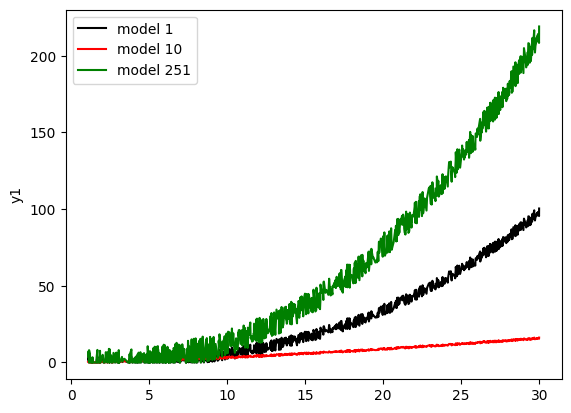

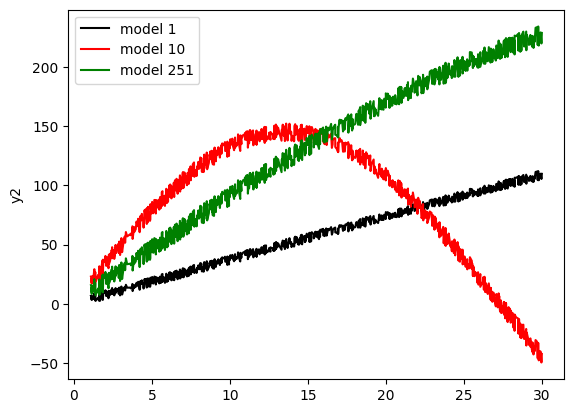

In [8]:
srt_idx = np.argsort(indata)
ax = plt.axes()
ax.plot(indata[srt_idx], obsdata['y1'][srt_idx,0], 'k-', label='model 1')
ax.plot(indata[srt_idx], obsdata['y1'][srt_idx,9], 'r-', label='model 10')
ax.plot(indata[srt_idx], obsdata['y1'][srt_idx,ex_idx], 'g-', label=f'model {ex_idx+1}')
ax.set_ylabel('y1')
ax.legend()
plt.show()

ax = plt.axes()
ax.plot(indata[srt_idx], obsdata['y2'][srt_idx,0], 'k-', label='model 1')
ax.plot(indata[srt_idx], obsdata['y2'][srt_idx,9], 'r-', label='model 10')
ax.plot(indata[srt_idx], obsdata['y2'][srt_idx,ex_idx], 'g-', label=f'model {ex_idx+1}')
ax.set_ylabel('y2')
ax.legend()
plt.show()

In [9]:
print(obsdata['y1'].shape)

(1000, 300)


## Conducting a Sensitivity Analysis

The sensitivity analysis is often a very useful way to get a feel for a model, and is a great exploratory step to determine what thresholds you would like to start with for the actual calibration later on.

This step introduces the Setup Class, used for both the sensitivity analysis and the calibration algorithm. This is the key ingredient for the MSCUA multidimensional algorithm. The Setup Class is the custom class that links your model to the database, and the relevant algorithm methods. The structure can remain the same but most things will need to be tailored to your model.

In [10]:
class MscuaSetupSA:
    # Define parameters here (before __init__) as variables
    # These are the parameters specific to your model and will need to be defined for each MscuaSetup class
    coef = spotpy.parameter.Uniform(low=0.009, high=0.15)
    exp = spotpy.parameter.Uniform(low=1.0, high=4.0)

    def __init__(self, objective_funcs, dbase: Optional[Union[str, Path, MultiDimDb]] = None):
        # define the multidimensional parameter space here
        # if using spatial data this would be the number of features you are calibrating
        self.parameter_dimension = num_models

        # This customizes the dimension name that is carried through the database, here I used "curve" but this could be
        #   feature, model, field, HRU, whatever descriptive name the parameter is attached to.
        self.param_dim_names = 'curve'

        # These attributes may be specific to your model setup, in-data might be a file path to an input file for instance
        #   and observation data may come from another file.
        self.indata = mdindata
        self.observation_data = obsdata

        self.objfuncs = objective_funcs

    # This method must be in the setup class, it is called during calibration to run the model, its only input should be a set
    #   of parameters. This could be an ordered list, tuple, however you want to set it up. I used a dictionary because it maintains
    #   reference to the parameter name and then you don't have to worry about order. This returns model output...for more complex model
    #   setups you might have a lot of code here to ingest parameters, change the parameters in the model files, and process the model outputs
    #   so that they can be returned as a Python object.
    def simulation(self, paramdict):
        modout = exp_model(self.indata, **paramdict)
        return modout
        
    # This is a required method. It can be more complex if needed but it doesn't really need any arguments, it just needs to
    #   return the observation data to compare with the modeled data.
    def evaluation(self):
        return self.observation_data

    # This must return a dictionary where the keys are the objective function names
    # This is set up to calculate an entire 3D array of simulation results - dimensions (model reps, model vals, # models)
    # This can be customized to whatever you need for your model, the multidimensional objective functions included above can be manipulated by
    #   passing the axis argument (calculated objective function on a particular axis or for the entire array) they also include an option to return a
    #   dictionary with the objective function name (default is to just return numpy array), this dictionary is necessary for tracking results
    #   through the algorithm for each objective function.
    def objectivefunction(self, observation, simulation):
        results = {}
        for ts in tqdm.tqdm(self.objfuncs.keys(), desc="Calculating Objective Functions", leave=False):
            results[ts] = {}
            if isinstance(self.objfuncs[ts], list):
                for o in self.objfuncs[ts]:
                    r = o(observation=observation[ts], simulation=simulation[ts], return_dict=True)
                    results[ts].update(r)
            else:
                o = self.objfuncs[ts]
                r = o(observation=observation[ts], simulation=simulation[ts], return_dict=True)
                results[ts].update(r)
        return results

Now initialize the setup class with the normalized root mean square error objective function calculated over both sets of outputs, as well as pbias calculated over the second set of output y-values.

In [11]:
SAsetup = MscuaSetupSA({'y1': nrmse_md, 'y2': [nrmse_md, nse_md]})

And plug that into the Sensitivity Analysis class.

In [12]:
sa = SensitivityAnalysis(SAsetup)

Now we will run the ```.sample()``` method which will lightly sample the parameter space based on the reps argument (default is 10), run the model, calculate objective function values, and determine the sensitivity of the objective function to the variation in each parameter value.

In [13]:
sa.sample()

Sampling 10 repetitions of the coef parameter...


Sampling 10 repetitions of the exp parameter...


The results of the sensitivity analysis are stored as an xarray dataset.

In [14]:
sa.results

<xarray.Dataset> Size: 209kB
Dimensions:              (parameters: 2, repetitions: 10, curve: 300,
                          objective_functions: 3)
Coordinates:
  * parameters           (parameters) <U4 32B 'coef' 'exp'
  * repetitions          (repetitions) int64 80B 1 2 3 4 5 6 7 8 9 10
  * curve                (curve) int64 2kB 1 2 3 4 5 6 ... 296 297 298 299 300
  * objective_functions  (objective_functions) <U8 96B 'nrmse_y1' ... 'nse_y2'
Data variables:
    samples              (parameters, repetitions, curve) float64 48kB dask.array<chunksize=(2, 10, 300), meta=np.ndarray>
    nrmse_y1             (parameters, repetitions, curve) float64 48kB dask.array<chunksize=(2, 10, 300), meta=np.ndarray>
    nrmse_y2             (parameters, repetitions, curve) float64 48kB dask.array<chunksize=(2, 10, 300), meta=np.ndarray>
    nse_y2               (parameters, repetitions, curve) float64 48kB dask.array<chunksize=(2, 10, 300), meta=np.ndarray>
    sensitivity_index    (objective_functions, parameters, curve) float64 14kB dask.array<chunksize=(3, 2, 300), meta=np.ndarray>

There are three different plotting functions to visualize these results.

The first, ```plot_obj_func()```, shows the value of the objective function at each of the sampled parameter values for a given model index.

Make sure to create a new plot for each of the available objective function/y-value combination.

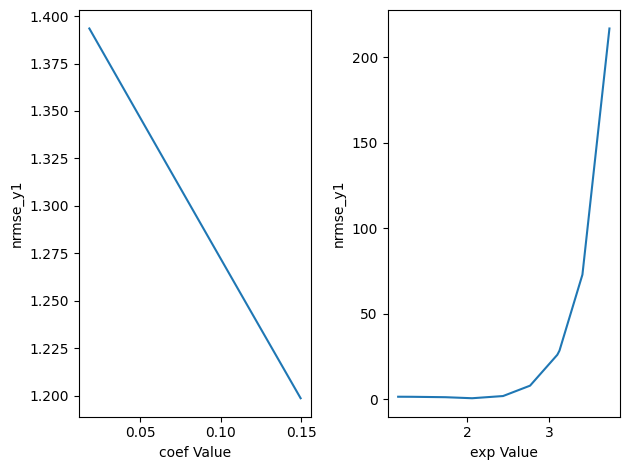

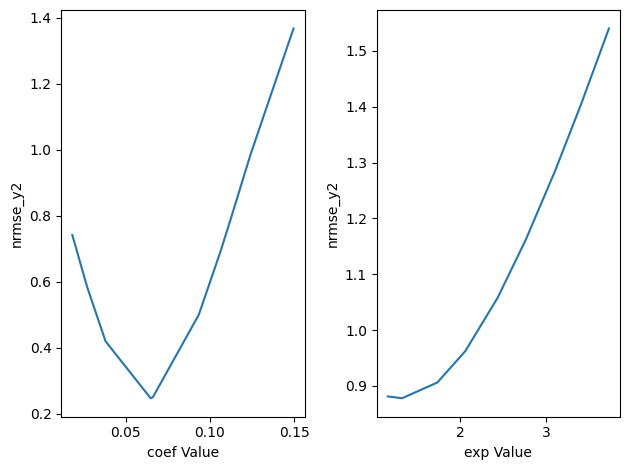

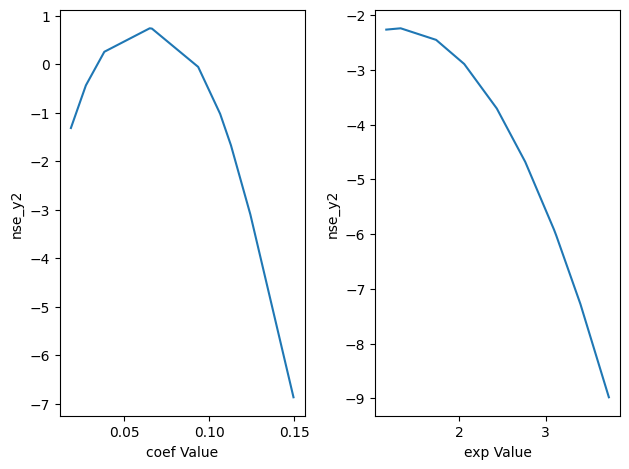

In [15]:
for of in sa.results.objective_functions.values:
    sa.plot_obj_func(of, ex_idx)

The second shows the "sensitivity index", or the relative sensitivity of the model's performance to variations in each parameter value. Here, we can see that the "exp" parameter has greater impact on this model than the "coef" parameter for the y1 values, but the two parameters are more balanced for the y2 values. This makes sense when thinking about an exponential function versus a sine function.

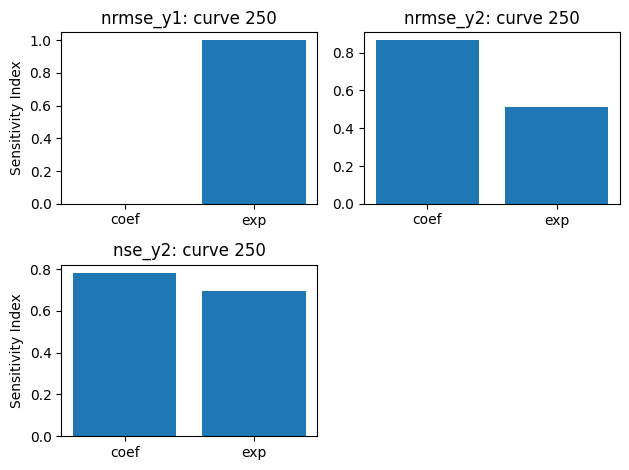

In [16]:
sa.plot_sensitivity_index(ex_idx)

Finally, the third function allows us to see the distribution of those sensitivity indices for the different parameters across all 300 models. These show that the pattern is consistent across all models; "exp" is the more important parameter in terms of overall model performance.

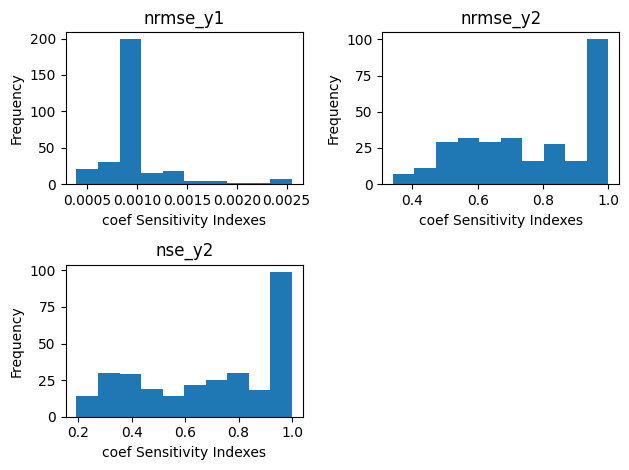

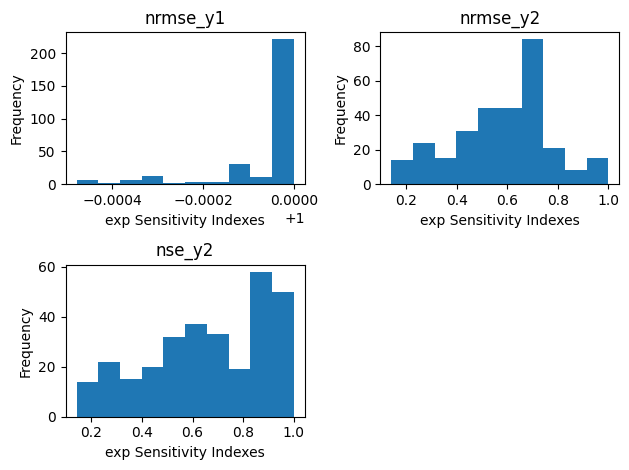

In [17]:
sa.plot_sensitivity_distribution('coef')

sa.plot_sensitivity_distribution('exp')

There is one last thing to look at before we move on to the full calibration. Now that we have run the model a few times, what sort of values of the objective function might we expect?

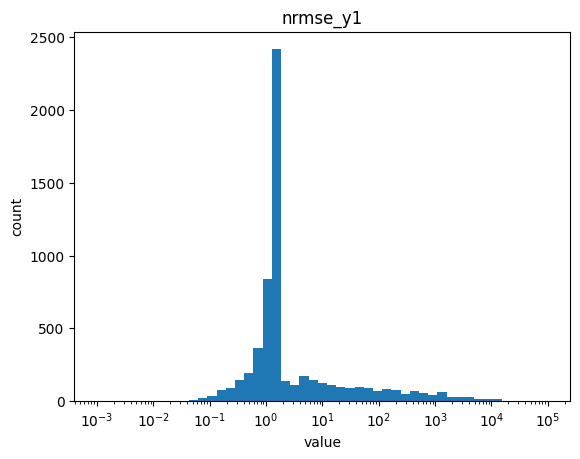

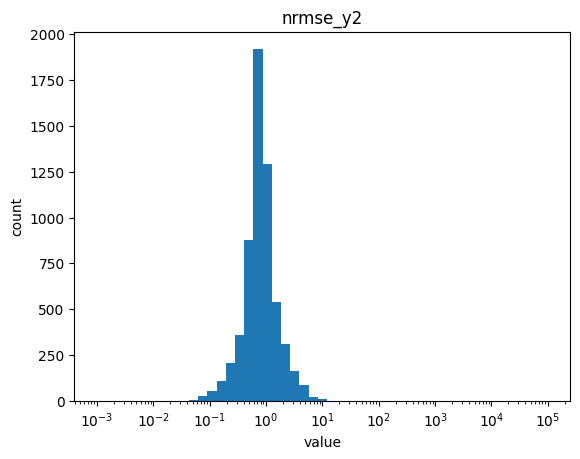

0.9935900155016891 -447.9229903802097


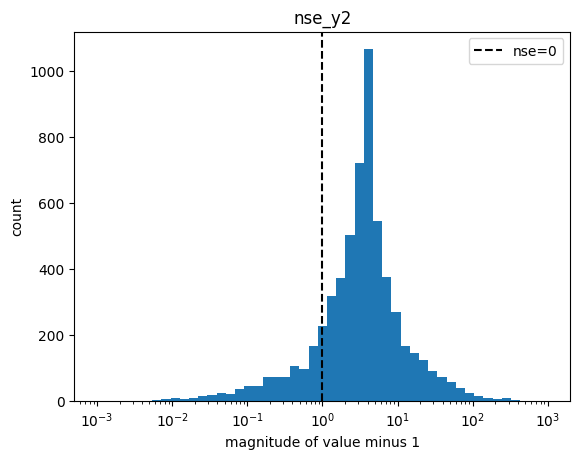

In [18]:
for of in sa.results.objective_functions.values:
    plt.figure()
    plt.title(of)
    
    if of.split('_')[0] == 'nrmse':
        plt.hist(sa.results[of].values.flatten(), np.logspace(-3, 5))
        plt.xlabel('value')
    elif of.split('_')[0] == 'nse':
        print(sa.results[of].values.flatten().max(), sa.results[of].values.flatten().min())
        plt.hist(np.abs(sa.results[of].values.flatten() - 1), np.logspace(-3, 3))  # , np.geomspace(-500, -0.001)) 
        plt.xlabel('magnitude of value minus 1')
        plt.axvline(1, label='nse=0', color='k', ls='dashed')
        plt.legend()
    plt.xscale('log')
    plt.ylabel('count')
    plt.show()

# plt.figure()
# plt.hist(sa.results.nrmse.values.flatten(), np.logspace(-2, 5))
# plt.xscale('log')
# plt.xlim(0.02, 100000)
# plt.show()

By looking at the plot above, we see that already, many model runs are able to achieve an nrmse value of less than 10 for y1, although many poorly-performing model runs are much above that. However, the majority of these model runs are getting values around 1 for nrmse. While these graphs don't tell us if the distribution is uniform across all 300 of our models, we probably want our objective function threshold to be within the range of previously-observed values, and a little optimistic.

## Calibration Iteration 1

Now we define the Setup Class for the calibration algorithm. This will be very, very similar to the one defined earlier for the sensitivity analysis, but note the ```axis=1``` agrument in ```objectivefunction()```.

In [19]:
class MscuaSetupIter1:
    # Define parameters here (before __init__) as variables
    # These are the parameters specific to your model and will need to be defined for each MscuaSetup class
    coef = spotpy.parameter.Uniform(low=0.009, high=0.15)
    exp = spotpy.parameter.Uniform(low=1.0, high=4.0)

    def __init__(self, objective_funcs, dbase: Optional[Union[str, Path, MultiDimDb]] = None):
        # define the multidimensional parameter space here
        # if using spatial data this would be the number of features you are calibrating
        self.parameter_dimension = num_models

        # This customizes the dimension name that is carried through the database, here I used "curve" but this could be
        #   feature, model, field, HRU, whatever descriptive name the parameter is attached to.
        self.param_dim_names = 'curve'
        
        # These attributes may be specific to your model setup, in-data might be a file path to an input file for instance
        #   and observation data may come from another file.
        self.indata = mdindata
        self.observation_data = obsdata

        self.objfuncs = objective_funcs

    # This method must be in the setup class, it is called during calibration to run the model, its only input should be a set
    #   of parameters. This could be an ordered list, tuple, however you want to set it up. I used a dictionary because it maintains
    #   reference to the parameter name and then you don't have to worry about order. This returns model output...for more complex model
    #   setups you might have a lot of code here to ingest parameters, change the parameters in the model files, and process the model outputs
    #   so that they can be returned as a Python object.
    def simulation(self, paramdict):
        modout = exp_model(self.indata, **paramdict)

        return modout
        
    # This is a required method. It can be more complex if needed but it doesn't really need any arguments, it just needs to
    #   return the observation data to compare with the modeled data.
    def evaluation(self):
        return self.observation_data

    # This must return a dictionary where the keys are the objective function names
    # This is set up to calculate an entire 3D array of simulation results - dimensions (model reps, model vals, # models)
    # This can be customized to whatever you need for your model, the multidimensional objective functions included above can be manipulated by
    #   passing the axis argument (calculated objective function on a particular axis or for the entire array) they also include an option to return a
    #   dictionary with the objective function name (default is to just return numpy array), this dictionary is necessary for tracking results
    #   through the algorithm for each objective function.
    def objectivefunction(self, observation, simulation):
        results = {}
        for ts in tqdm.tqdm(self.objfuncs.keys(), desc="Calculating Objective Functions", leave=False):
            results[ts] = {}
            if isinstance(self.objfuncs[ts], list):
                for o in self.objfuncs[ts]:
                    r = o(observation=observation[ts], simulation=simulation[ts], return_dict=True, axis=1)
                    results[ts].update(r)
            else:
                o = self.objfuncs[ts]
                r = o(observation=observation[ts], simulation=simulation[ts], return_dict=True, axis=1)
                results[ts].update(r)
        
        return results

Next, initialize the setup class with the appropriate objective function(s) for each of the observed value sets.

In [20]:
setup = MscuaSetupIter1({'y1': nrmse_md, 'y2': [nrmse_md, nse_md]})

And initialize a new MsCua Sampler.

In [21]:
sampler = MsCua(setup)

In Memory database initialized...


Now we will run the ```.sample()``` method which will sample the parameters space based on the reps argument, run the model, calculate objective function values, and filter parameter distributions based on the provided thresholds. The ```.sample()``` method will return index arrays if certain threshold requirements are not met. While most of the work writes directly to the database, I assign the output "results" variable to capture any failed iterations. This can be used later to filter those problem indexes out.

In [22]:
results = sampler.sample(1000, {'y1': {'nrmse': 0.7}, 'y2': {'nrmse': 0.7, 'nse': 0.15}}, 
                         use_distribution=False)

Sampling 1000 repetitions of the coef parameter...


Sampling 1000 repetitions of the exp parameter...


Running model for 1000 repetitions in database...


Evaluating Objective Function Values...


Max number of refined parameter sets: 71
Min number of refined parameter sets: 5

y1
  Calculating the 95PPU...
  Calculating p- and r-factor metrics...
  Max p-factor = 0.978
  Min p-factor = 0.512
  Min r-factor = 0.4098548977397772
  Max r-factor = 1.7279292892417133

y2
  Calculating the 95PPU...
  Calculating p- and r-factor metrics...
  Max p-factor = 1.0
  Min p-factor = 0.791
  Min r-factor = 0.7689977885233733
  Max r-factor = 1.7401789593117374

49 models had fewer than the minimum allowable refined parameter sets: 25. Either increase the number of samples or exclude these models.
Returning array of failed model indexes.
All models had p-factor greater than 0.35


As I said, all the algorithm operations are saved to the database, which we now convert to an xarray Dataset for easier indexing and handling.

In [23]:
cal_ds = sampler.database.to_xarray_dict()

In [24]:
cal_ds

<xarray.Dataset> Size: 5GB
Dimensions:                       (repetition: 1000, curve: 300,
                                   observation_y1: 1000,
                                   objective_functions: 2, parameters: 2,
                                   observation_y2: 1000, scalar: 1)
Coordinates:
  * repetition                    (repetition) int64 8kB 1 2 3 ... 998 999 1000
  * curve                         (curve) int64 2kB 1 2 3 4 ... 297 298 299 300
  * observation_y1                (observation_y1) int64 8kB 1 2 3 ... 999 1000
  * objective_functions           (objective_functions) <U5 40B 'nrmse' 'nse'
  * parameters                    (parameters) <U4 32B 'coef' 'exp'
  * observation_y2                (observation_y2) int64 8kB 1 2 3 ... 999 1000
Dimensions without coordinates: scalar
Data variables: (12/28)
    coef_samples                  (repetition, curve) float64 2MB 0.08105 ......
    exp_samples                   (repetition, curve) float64 2MB 1.902 ... 2.32
    coef_refined                  (repetition, curve) float64 2MB nan ... nan
    exp_refined                   (repetition, curve) float64 2MB nan ... nan
    nrmse_y1                      (repetition, curve) float64 2MB 0.5878 ... ...
    best_simulation_nrmse_y1      (observation_y1, curve) float64 2MB 0.5317 ...
    ...                            ...
    95PPU_lower_y2                (observation_y2, curve) float64 2MB 11.12 ....
    95PPU_upper_y2                (observation_y2, curve) float64 2MB 20.26 ....
    obj_func_thresholds_y1        (objective_functions) float64 16B 0.7 0.0
    obj_func_thresholds_y2        (objective_functions) float64 16B 0.7 0.15
    pfactor_threshold             (scalar) float64 8B 0.35
    min_refined_params_threshold  (scalar) int64 8B 25

The ```MsCuaAnalyzer``` class provides easy ways to plot and run diagnostics on the current MsCua iteration. You can initialize this class with a database or an xarray Dataset created from a database.

In [25]:
cal_ds

<xarray.Dataset> Size: 5GB
Dimensions:                       (repetition: 1000, curve: 300,
                                   observation_y1: 1000,
                                   objective_functions: 2, parameters: 2,
                                   observation_y2: 1000, scalar: 1)
Coordinates:
  * repetition                    (repetition) int64 8kB 1 2 3 ... 998 999 1000
  * curve                         (curve) int64 2kB 1 2 3 4 ... 297 298 299 300
  * observation_y1                (observation_y1) int64 8kB 1 2 3 ... 999 1000
  * objective_functions           (objective_functions) <U5 40B 'nrmse' 'nse'
  * parameters                    (parameters) <U4 32B 'coef' 'exp'
  * observation_y2                (observation_y2) int64 8kB 1 2 3 ... 999 1000
Dimensions without coordinates: scalar
Data variables: (12/28)
    coef_samples                  (repetition, curve) float64 2MB 0.08105 ......
    exp_samples                   (repetition, curve) float64 2MB 1.902 ... 2.32
    coef_refined                  (repetition, curve) float64 2MB nan ... nan
    exp_refined                   (repetition, curve) float64 2MB nan ... nan
    nrmse_y1                      (repetition, curve) float64 2MB 0.5878 ... ...
    best_simulation_nrmse_y1      (observation_y1, curve) float64 2MB 0.5317 ...
    ...                            ...
    95PPU_lower_y2                (observation_y2, curve) float64 2MB 11.12 ....
    95PPU_upper_y2                (observation_y2, curve) float64 2MB 20.26 ....
    obj_func_thresholds_y1        (objective_functions) float64 16B 0.7 0.0
    obj_func_thresholds_y2        (objective_functions) float64 16B 0.7 0.15
    pfactor_threshold             (scalar) float64 8B 0.35
    min_refined_params_threshold  (scalar) int64 8B 25

In [26]:
ana = MsCuaAnalyzerDict(cal_ds)

Let's plot all the diagnostics from this iteration.

p-factor determines the percent overlap between the 95% percentile prediction uncertainty (95PPU) and the observed data. p-factor ranges from 0 - 1 with 1 meaning that all obesrved data are contained within the 95PPU. This has a default threshold of 0.35. You can see in the distribution that all of the 300 models calibrated were above the threshold.

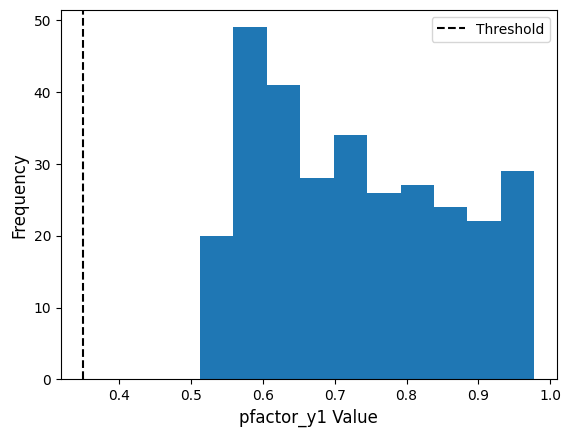

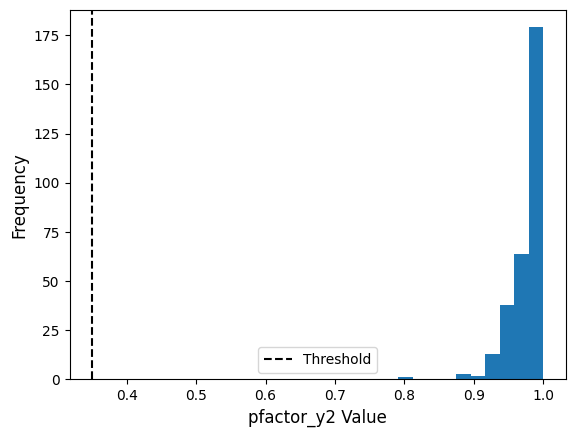

In [27]:
ana.plot_pfactor(threshold=True)

The r-factor compares the spread of the measured data with the spread of the 95PPU. This is an additional diagnostic to the p-factor which can be misleading if your 95PPU is REALLY large, it will obviously contain all the observed data points. r-factor can range from 0 to infinity and a lower value is better (low r-factor with high p-factor is ideal).

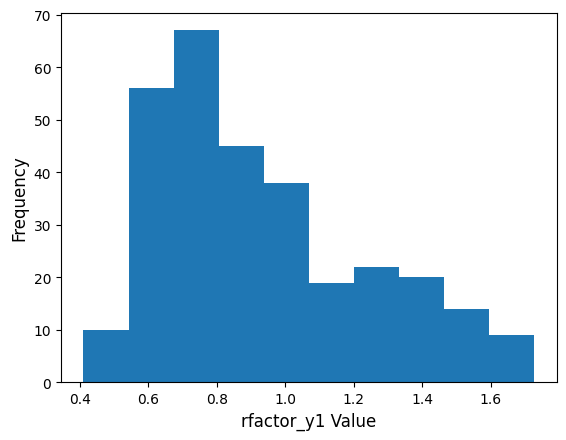

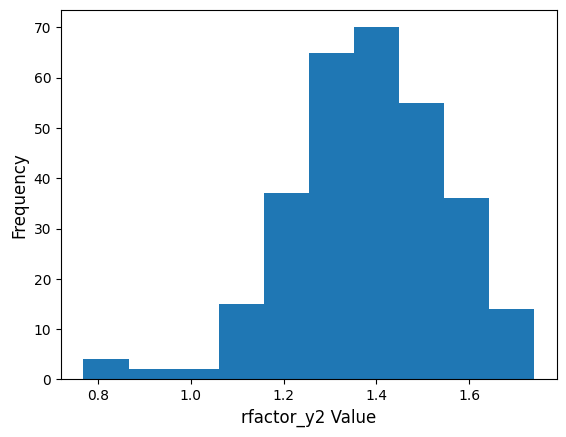

In [28]:
ana.plot_rfactor()

We can also plot the refined distribution of each of the calibrated parameters.

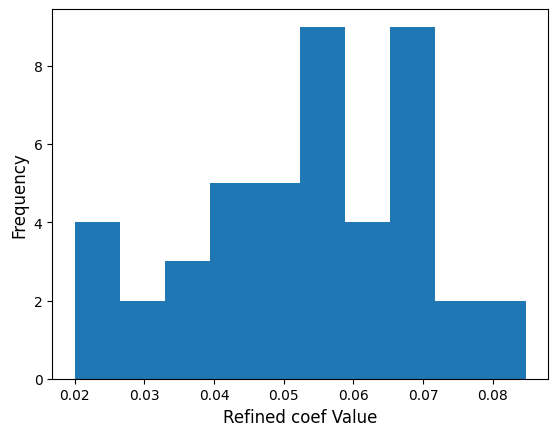

In [29]:
ana.plot_refined_parameters(param='coef', indx=ex_idx)

Or, compare the pre- and post- calibration parameter distributions. Obviously in this case our pre-distribution was just a Uniform distribution for a given range.

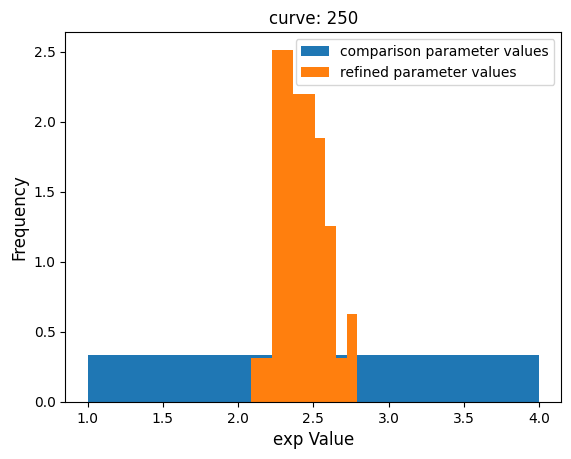

In [30]:
ana.compare_parameter_distributions('exp', comp_dstb=cal_ds.exp_samples.values[:,ex_idx], indx=ex_idx, density=True)

We can also use the analyzer class to look at the distribution of objective function values for each model over the number of repititions.

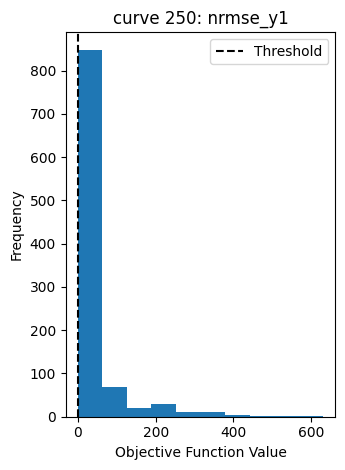

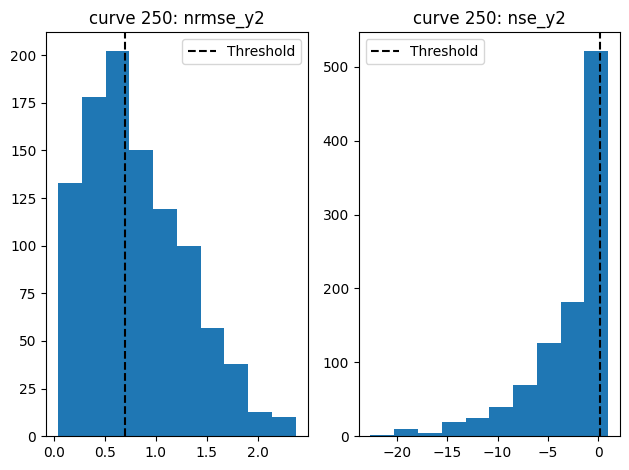

In [31]:
ana.plot_objective_functions(ex_idx, threshold=True)

Plot the 95PPU with observation data and the best simulation result for the current interation.

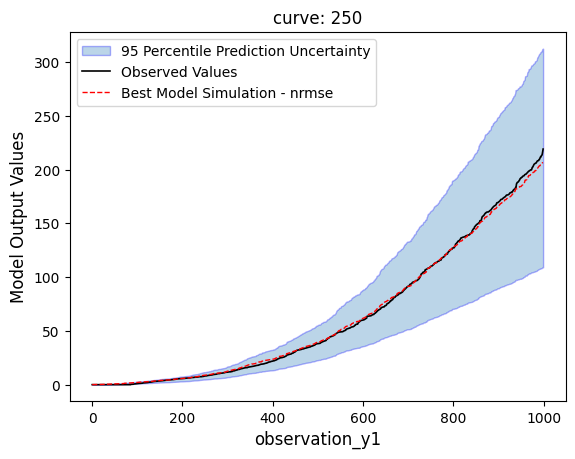

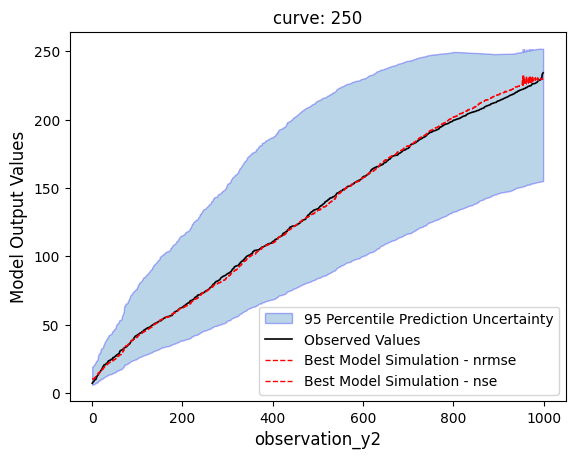

In [32]:
# nobsdat = np.where(obsdata < 0, 0, obsdata)
for i in ['y1', 'y2']:
    ana.plot_ppu(ex_idx, best_sim=True, obs_data=obsdata[i], sort=True, series=i)


We can plot the values (for each model) of the best objective function result that defines the best simulation for the current iteration.

nrmse_y1


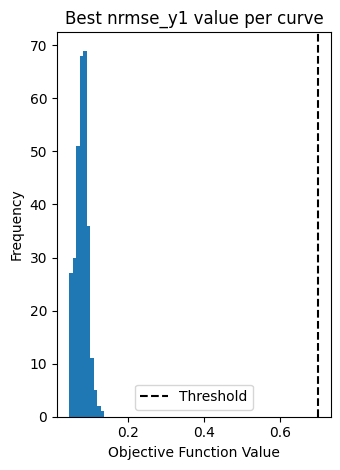

nrmse_y2
nse_y2


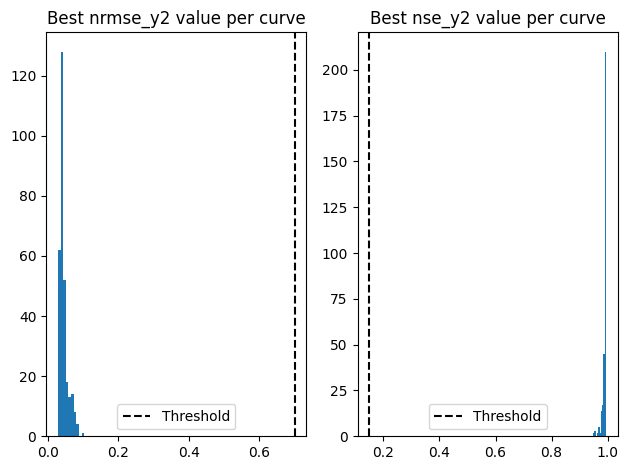

In [33]:
ana.plot_best_objfuncs(threshold=True)

We can also plot the number of refined parameter sets (the parameter sets for each model that were not filtered out by the objective function thresholds).

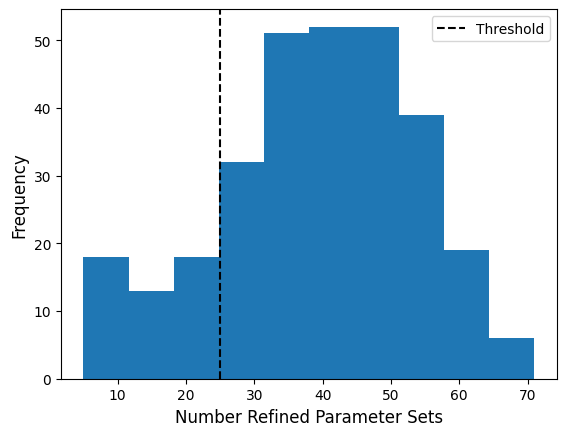

In [34]:
ana.plot_number_refined_params(threshold=True)

Next we can observe how the parameter distributions were altered during the current iteration.

First, we'll select only the successful models.

In [35]:
results

array([  0,   1,  10,  17,  20,  21,  31,  71,  75,  78,  81,  92, 100,
       106, 113, 117, 118, 122, 124, 125, 135, 140, 142, 145, 154, 160,
       161, 167, 170, 172, 174, 186, 188, 190, 194, 197, 209, 212, 213,
       214, 225, 243, 259, 262, 263, 266, 271, 284, 286])

In [36]:
crves = np.arange(num_models)

if len(np.shape(results)) > 1:
    for failed in results:
        if len(failed) > 0:
            success = np.delete(crves, failed)
        else:
            success = crves
else:
    failed = results
    success = np.delete(crves, failed)

Now we loop through each successful model and use the analyzer class method ```.calc_param_distribution_change()``` which uses the Wasserstein Distance to measure the difference between the pre- and post- iteration parameter distributions.

In [37]:
wd = dict()
for par in ['coef', 'exp']:
    wd[par] = []
    for i in success:
        dist = ana.calc_param_distribution_change(par, comp_dstb=cal_ds[f'{par}_samples'].values[:,i], indx=i)
        wd[par].append(dist)
    wd[par] = np.array(wd[par])

The Wasserstein distance measures a relative amount of change that would need to occur to transform one distribution into the other. A value of 0.0 would mean the two ditributions are identical whereas a larger value means the two distributions are more different. Plotting the results for all the successful models, you see that the coef parameter did not change as much before and after this iteration (which is because mathematically it is less sensitive). The exp parameter though showed much higher values for nearly every successful model.

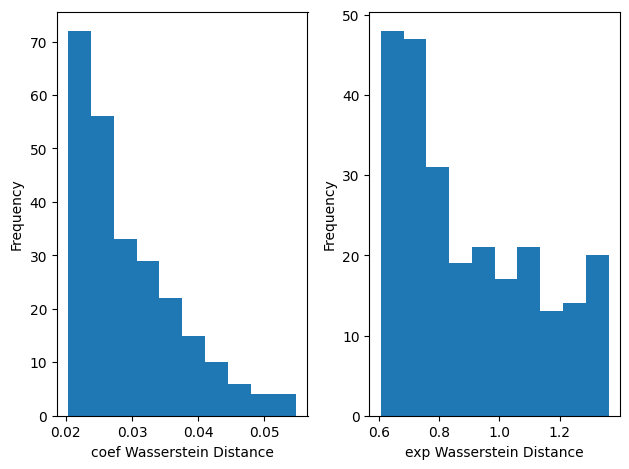

In [38]:
fig, axs = plt.subplots(1, 2)
axs[0].hist(wd['coef'])
axs[1].hist(wd['exp'])
axs[0].set_xlabel("coef Wasserstein Distance")
axs[1].set_xlabel("exp Wasserstein Distance")
axs[0].set_ylabel("Frequency")
axs[1].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

Finally, the last test we can do is to compare the calibrated parameters with the initial input parameters (since in this theoretical example we know what each model's parameter was). We could do this in a probabalistic way, comparing the distribution of the refined parameters, or the median of the refined distribution, or we could use the parameter value with the best objective function result...this is visualized in the following plot...

In [39]:
cal_ds

<xarray.Dataset> Size: 5GB
Dimensions:                       (repetition: 1000, curve: 300,
                                   observation_y1: 1000,
                                   objective_functions: 2, parameters: 2,
                                   observation_y2: 1000, scalar: 1)
Coordinates:
  * repetition                    (repetition) int64 8kB 1 2 3 ... 998 999 1000
  * curve                         (curve) int64 2kB 1 2 3 4 ... 297 298 299 300
  * observation_y1                (observation_y1) int64 8kB 1 2 3 ... 999 1000
  * objective_functions           (objective_functions) <U5 40B 'nrmse' 'nse'
  * parameters                    (parameters) <U4 32B 'coef' 'exp'
  * observation_y2                (observation_y2) int64 8kB 1 2 3 ... 999 1000
Dimensions without coordinates: scalar
Data variables: (12/28)
    coef_samples                  (repetition, curve) float64 2MB 0.08105 ......
    exp_samples                   (repetition, curve) float64 2MB 1.902 ... 2.32
    coef_refined                  (repetition, curve) float64 2MB nan ... nan
    exp_refined                   (repetition, curve) float64 2MB nan ... nan
    nrmse_y1                      (repetition, curve) float64 2MB 0.5878 ... ...
    best_simulation_nrmse_y1      (observation_y1, curve) float64 2MB 0.5317 ...
    ...                            ...
    95PPU_lower_y2                (observation_y2, curve) float64 2MB 11.12 ....
    95PPU_upper_y2                (observation_y2, curve) float64 2MB 20.26 ....
    obj_func_thresholds_y1        (objective_functions) float64 16B 0.7 0.0
    obj_func_thresholds_y2        (objective_functions) float64 16B 0.7 0.15
    pfactor_threshold             (scalar) float64 8B 0.35
    min_refined_params_threshold  (scalar) int64 8B 25

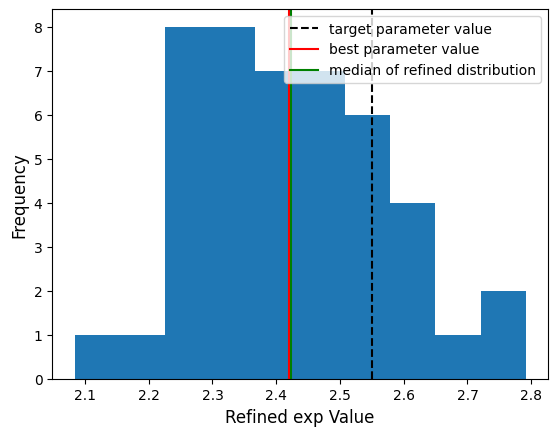

In [40]:
ax = plt.axes()
ax.axvline(target_exp[ex_idx], color='black', ls='--', label='target parameter value')
ax.axvline(cal_ds.best_parameter_set_y1.sel(objective_functions='nrmse', parameters='exp', curve=ex_idx+1).values, color='red', label='best parameter value')
ax.axvline(np.nanmedian(cal_ds.exp_refined.values[:,ex_idx]), color='green', label='median of refined distribution')
ax.legend()
ana.plot_refined_parameters('exp', ex_idx, ax=ax)

You can see that the median and the best simulation are slightly different from the true parameter value but both are pretty close. Let's look at all the models together using the best simulation parameter sets...

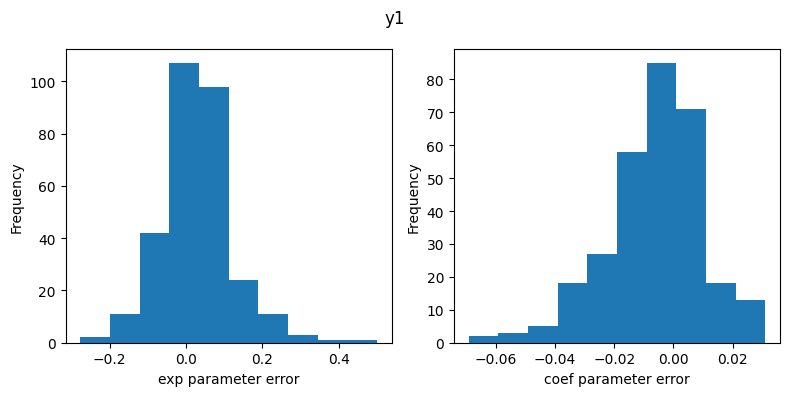

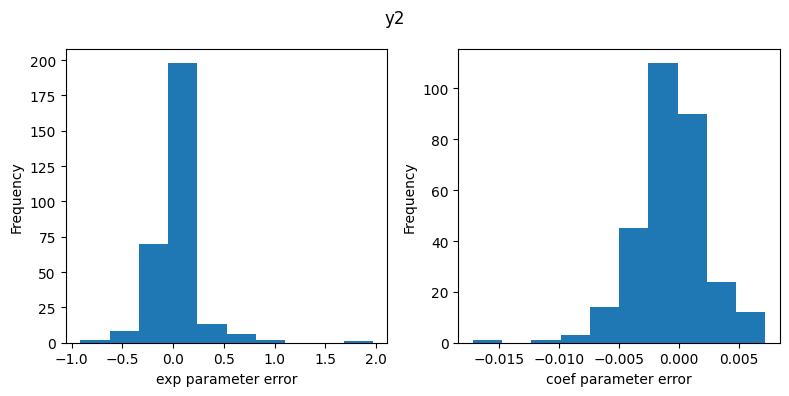

In [41]:
# Why are these not working?

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
plt.suptitle("y1")
axs[0].hist(target_exp - cal_ds.best_parameter_set_y1.sel(objective_functions='nrmse', parameters='exp').values)
axs[0].set_ylabel("Frequency")
axs[0].set_xlabel("exp parameter error")
axs[1].hist(target_coef - cal_ds.best_parameter_set_y1.sel(objective_functions='nrmse', parameters='coef').values)
axs[1].set_ylabel("Frequency")
axs[1].set_xlabel("coef parameter error")
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
plt.suptitle("y2")
axs[0].hist(target_exp - cal_ds.best_parameter_set_y2.sel(objective_functions='nrmse', parameters='exp').values)
axs[0].set_ylabel("Frequency")
axs[0].set_xlabel("exp parameter error")
axs[1].hist(target_coef - cal_ds.best_parameter_set_y2.sel(objective_functions='nrmse', parameters='coef').values)
axs[1].set_ylabel("Frequency")
axs[1].set_xlabel("coef parameter error")
plt.tight_layout()
plt.show()

While most of the models had a parameter error close to 0.0, there is still a decent spread to these differences. This is because our objective function threshold was rather lax. Let's do another iteration with a much more stringent threshold...

But first, let's save our database as a netcdf. Just to show that we can, and in case we want to recall any of that information later (remember, our Analyzer class can accept an xarray Dataset so we can revisit iteration 1 diagnostics whenever OR compare them to later iterations).

In [42]:
# cal_ds.to_netcdf('Dual_Model_MSCUA_Iteration_1.nc')

## Interlude: Failed Models

Before we do another iteration, we should deal with our failed models, those that did not retain more than 25 refined parameter sets and/or had a p-factor < 0.35.

These probably failed because they were not well represented in the parameter samples...that can be fixed by increasing the sample size, or relaxing the objective function thresholds. A recommended approach for dealing with these would be to remove them completely and run a separate calibration for those problematic models. For this example, we will isolate those models and use our diagnostics to narrow our parameter search range and see if we can get them to meet the criteria, then we will add them back into our 1st iteration run before beginning iteration 2. If you have a model with significant runtime, you might choose to relax the objective functions instead of add more samples or do additional calibration schemes first. Just don't relax them TOO MUCH!!

Now we will isolate the relevant observation data for our failed models.

In [43]:
failed

array([  0,   1,  10,  17,  20,  21,  31,  71,  75,  78,  81,  92, 100,
       106, 113, 117, 118, 122, 124, 125, 135, 140, 142, 145, 154, 160,
       161, 167, 170, 172, 174, 186, 188, 190, 194, 197, 209, 212, 213,
       214, 225, 243, 259, 262, 263, 266, 271, 284, 286])

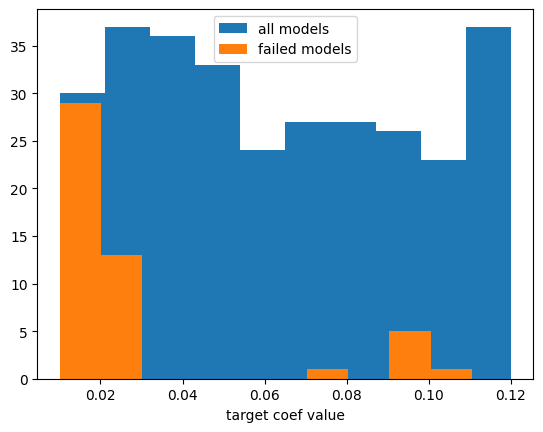

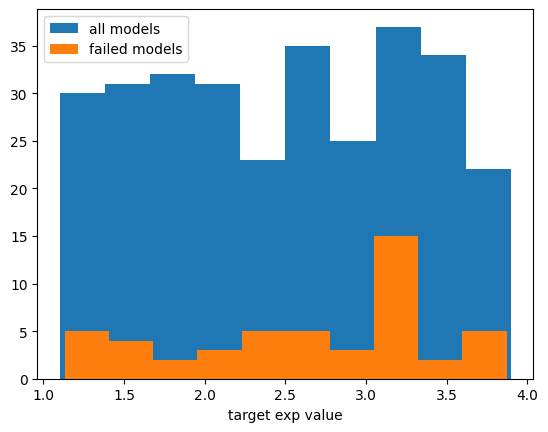

In [44]:

plt.figure()
plt.hist(target_coef, label='all models')
plt.hist(target_coef[failed], label='failed models')
plt.xlabel('target coef value')
plt.legend()
plt.show()

plt.figure()
plt.hist(target_exp, label='all models')
plt.hist(target_exp[failed], label='failed models')
plt.xlabel('target exp value')
plt.legend()
plt.show()

In [45]:
failed_obsdat = dict()

for i in ['y1', 'y2']:
    failed_obsdat[i] = obsdata[i][:, failed]

# failed_obsdat

Now, we can check our best parameter set from iteration 1 because even though the models failed our criteria, they still had 1000 different simulations and a "best" objective function result.

In [46]:
cal_ds.best_parameter_set_y1.sel(objective_functions='nrmse', parameters='coef').values[failed]

array([0.01153353, 0.14536925, 0.01875712, 0.03859261, 0.13882468,
       0.013051  , 0.02589003, 0.01727765, 0.0148089 , 0.01092075,
       0.01269304, 0.01610304, 0.01978732, 0.02189628, 0.03066031,
       0.02003999, 0.01421573, 0.08521994, 0.05835548, 0.11570097,
       0.02044028, 0.05835548, 0.01727765, 0.01735006, 0.00941644,
       0.01727765, 0.03546544, 0.0163028 , 0.02778715, 0.01844074,
       0.02707867, 0.08652851, 0.01361327, 0.1237282 , 0.02874142,
       0.00968709, 0.01765427, 0.02003999, 0.08494528, 0.01092075,
       0.01710677, 0.02561701, 0.10303161, 0.03396826, 0.01390499,
       0.03741072, 0.00918197, 0.01928629, 0.07000484])

In [47]:
cal_ds.best_parameter_set_y2.sel(objective_functions='nrmse', parameters='coef').values[failed]

array([0.01316443, 0.09791256, 0.02180341, 0.01875712, 0.10929679,
       0.01367736, 0.01281186, 0.01518398, 0.01935279, 0.01806676,
       0.01901168, 0.01970225, 0.01367736, 0.02189628, 0.01518398,
       0.01670876, 0.01173638, 0.09923739, 0.02799883, 0.08005471,
       0.02166291, 0.02874142, 0.01778058, 0.00950365, 0.01791025,
       0.01518398, 0.03129128, 0.02707867, 0.02874142, 0.01806676,
       0.01928629, 0.01806676, 0.02189628, 0.1011138 , 0.02874142,
       0.00941644, 0.02863849, 0.01578365, 0.08986123, 0.01791025,
       0.02180341, 0.03013982, 0.09709336, 0.02968441, 0.01935279,
       0.01778058, 0.01012874, 0.02745309, 0.01947919])

We'll need a new setup class for the failed models. We just change a few things here from our previous setup:
1) adjust the parameter ranges
2) change our parameter dimensions to match the number of failed results
3) change our observation data to the failed observation data selection

That's all, everything else stays the same.

In [48]:
class MscuaSetupf1:
    # Define parameters here (before __init__) as variables
    coef = spotpy.parameter.Uniform(low=0.01, high=0.04)
    exp = spotpy.parameter.Uniform(low=1.0, high=4.0)

    def __init__(self, objective_funcs, dbase: Optional[Union[str, Path, MultiDimDb]] = None):
        self.parameter_dimension = failed_obsdat['y1'].shape[1]
        self.param_dim_names = 'curve'
        self.indata = mdindata
        self.observation_data = failed_obsdat
        
        self.objfuncs = objective_funcs
   
    def simulation(self, paramdict):
        modout = exp_model(self.indata, **paramdict)

        return modout
        
    def evaluation(self):
        return self.observation_data

    def objectivefunction(self, observation, simulation):
        results = {}
        for ts in tqdm.tqdm(self.objfuncs.keys(), desc="Calculating Objective Functions", leave=False):
            results[ts] = {}
            if isinstance(self.objfuncs[ts], list):
                for o in self.objfuncs[ts]:
                    r = o(observation=observation[ts], simulation=simulation[ts], return_dict=True, axis=1)
                    results[ts].update(r)
            else:
                o = self.objfuncs[ts]
                r = o(observation=observation[ts], simulation=simulation[ts], return_dict=True, axis=1)
                results[ts].update(r)
        
        return results
    
#     low=0.01, high=0.12, size=num_models)
# target_exp = np.random.uniform(low=1.1, high=3.9

Initialize the sampler and run ```.sample()``` just as before.

In [49]:
failed_setup = MscuaSetupf1({'y1': nrmse_md, 'y2': [nrmse_md, nse_md]})
failed_sampler = MsCua(failed_setup)

In Memory database initialized...


In [50]:
failed_results = failed_sampler.sample(1000, {'y1': {'nrmse': 0.8}, 'y2': {'nrmse': 0.8, 'nse': 0.2}})

Sampling 1000 repetitions of the coef parameter...


Sampling 1000 repetitions of the exp parameter...


Running model for 1000 repetitions in database...


Evaluating Objective Function Values...


c:\Users\CND571\.conda\envs\swim1\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Max number of refined parameter sets: 120
Min number of refined parameter sets: 0

y1
  Calculating the 95PPU...
  Calculating p- and r-factor metrics...
  Max p-factor = 0.97
  Min p-factor = 0.0
  Min r-factor = 0.6829209195760975
  Max r-factor = 1.7681560145832484

y2
  Calculating the 95PPU...
  Calculating p- and r-factor metrics...
  Max p-factor = 0.99
  Min p-factor = 0.0
  Min r-factor = 0.7715823532784704
  Max r-factor = 1.5237581034389565

7 models had fewer than the minimum allowable refined parameter sets: 25. Either increase the number of samples or exclude these models.
Returning array of failed model indexes.
7 models had a p-factor lower than the allowable minimum: 0.35. Returning array of failed indexes.


SUCCESS, by narrowing the parameter search ranges for our problem models, they have all met the criteria. Let's add them back to our original iteration database (you could also do this by editing the xarray dataset/netcdf, either way).

In [51]:
for k,v in sampler.database.refined_parameters.items():
    v[:,failed] = failed_sampler.database.refined_parameters[k]

Now we can check this operation was successful and see that no model has fewer than 25 refined parameter sets.

In [52]:
nans = np.isnan(sampler.database.refined_parameters['coef'])
nz = np.count_nonzero(~nans, axis=0)
print(nz.min())

0


## Calibration Iteration 2

Alright, next iteration time. Again, we make a setup class. This time, it is identical to our iteration 1 setup class except now, we are going to use the spotpy List parameter class instead of Uniform. And to initialize it, we will pass it the refined parameters from our 1st iteration. What this does functionally is similar to what we just did with the failed models. We are now running the whole algorithm again but starting from a more representative parameter distribution.

In [53]:
print(sampler.database.refined_parameters['coef'])
print(np.shape(sampler.database.refined_parameters['coef']))

[[       nan        nan        nan ... 0.08105106        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]
 ...
 [       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]]
(1000, 300)


In [54]:
class MscuaSetupIter2:
    # Define parameters here (before __init__) as variables
    coef = spotpy.parameter.List('coef', sampler.database.refined_parameters['coef'])  # does it need a name?
    exp = spotpy.parameter.List('exp', sampler.database.refined_parameters['exp'])

    def __init__(self, objective_funcs, dbase: Optional[Union[str, Path, MultiDimDb]] = None):
        self.parameter_dimension = num_models
        self.param_dim_names = 'curve'
        self.indata = mdindata
        self.observation_data = obsdata
        
        self.objfuncs = objective_funcs
   
    def simulation(self, paramdict):
        modout = exp_model(self.indata, **paramdict)

        return modout
        
    def evaluation(self):
        return self.observation_data

    def objectivefunction(self, observation, simulation):
        results = {}
        for ts in tqdm.tqdm(self.objfuncs.keys(), desc="Calculating Objective Functions", leave=False):
            results[ts] = {}
            if isinstance(self.objfuncs[ts], list):
                for o in self.objfuncs[ts]:
                    r = o(observation=observation[ts], simulation=simulation[ts], return_dict=True, axis=1)
                    results[ts].update(r)
            else:
                o = self.objfuncs[ts]
                r = o(observation=observation[ts], simulation=simulation[ts], return_dict=True, axis=1)
                results[ts].update(r)
        
        return results

In [55]:
iter2_setup = MscuaSetupIter2({'y1': nrmse_md, 'y2': [nrmse_md, nse_md]})
iter2_sampler = MsCua(iter2_setup)

In Memory database initialized...


When we go to sample this time, let's lower our threshold to 0.4 from 0.6. This should give us more refined parameters but also filter lots out again.

In [56]:
iter2_results = iter2_sampler.sample(1000, {'y1': {'nrmse': 0.4}, 'y2': {'nrmse': 0.4, 'nse': 0.3}},
                                    use_distribution=False)

C:\Users\CND571\PycharmProjects\calmd\src\calmd\utils.py:46: RuntimeWarning: All-NaN slice encountered
  attrobj.maxbound = np.nanmax(attrobj.values, axis=0)
C:\Users\CND571\PycharmProjects\calmd\src\calmd\utils.py:47: RuntimeWarning: All-NaN slice encountered
  attrobj.minbound = np.nanmin(attrobj.values, axis=0)


Sampling 1000 repetitions of the coef parameter...


Sampling 1000 repetitions of the exp parameter...


Running model for 1000 repetitions in database...


Evaluating Objective Function Values...


Calculating Objective Functions:   0%|          | 0/2 [00:00<?, ?it/s]C:\Users\CND571\PycharmProjects\calmd\src\calmd\obj_funcs.py:14: RuntimeWarning: Mean of empty slice
  mse = np.nanmean((observation - simulation) ** 2, axis=axis)


Max number of refined parameter sets: 609
Min number of refined parameter sets: 0

y1
  Calculating the 95PPU...
  Calculating p- and r-factor metrics...
  Max p-factor = 0.974
  Min p-factor = 0.0
  Min r-factor = 0.3331371032346337
  Max r-factor = 1.115708902433879

y2
  Calculating the 95PPU...
  Calculating p- and r-factor metrics...
  Max p-factor = 0.999
  Min p-factor = 0.0
  Min r-factor = 0.6551311969270073
  Max r-factor = 1.4664031700027484

7 models had fewer than the minimum allowable refined parameter sets: 25. Either increase the number of samples or exclude these models.
Returning array of failed model indexes.
7 models had a p-factor lower than the allowable minimum: 0.35. Returning array of failed indexes.


Alright, that was a success, didn't have any failed models. Let's set up the Analyzer and run the same/similar diagnostics.

In [57]:
iter2_ds = iter2_sampler.database.to_xarray_dict()

In [58]:
iter2_ana = MsCuaAnalyzerDict(iter2_ds)

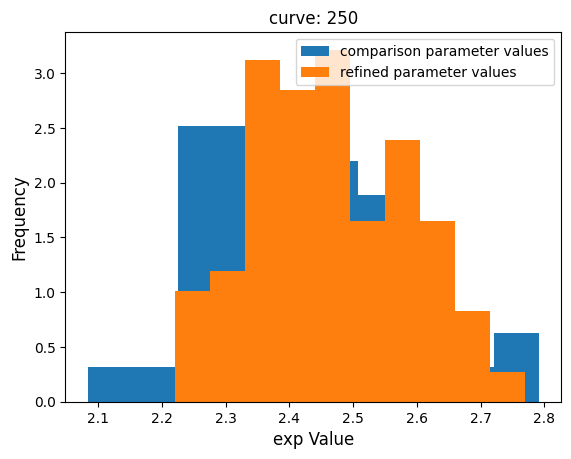

In [59]:
iter2_ana.compare_parameter_distributions('exp', comp_dstb=cal_ds.exp_refined.values[:,ex_idx], indx=ex_idx, density=True)

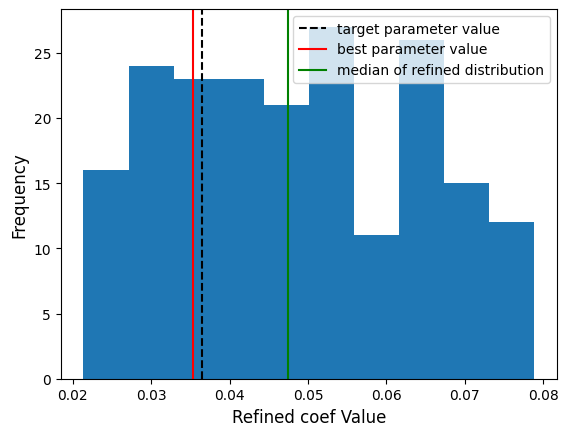

In [60]:
ax = plt.axes()
ax.axvline(target_coef[ex_idx], color='black', ls='--', label='target parameter value')
ax.axvline(iter2_ds.best_parameter_set_y1.sel(objective_functions='nrmse', parameters='coef', curve=ex_idx+1).values, color='red', label='best parameter value')
ax.axvline(np.nanmedian(iter2_ds.coef_refined.values[:,ex_idx]), color='green', label='median of refined distribution')
ax.legend()
iter2_ana.plot_refined_parameters('coef', ex_idx, ax=ax)

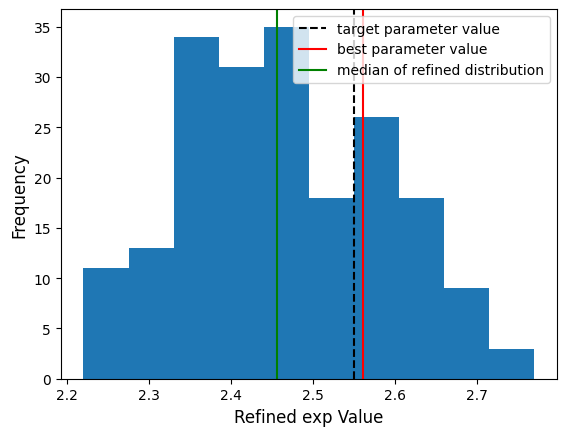

In [61]:
ax = plt.axes()
ax.axvline(target_exp[ex_idx], color='black', ls='--', label='target parameter value')
ax.axvline(iter2_ds.best_parameter_set_y1.sel(objective_functions='nrmse', parameters='exp', curve=ex_idx+1).values, color='red', label='best parameter value')
ax.axvline(np.nanmedian(iter2_ds.exp_refined.values[:,ex_idx]), color='green', label='median of refined distribution')
ax.legend()
iter2_ana.plot_refined_parameters('exp', ex_idx, ax=ax)

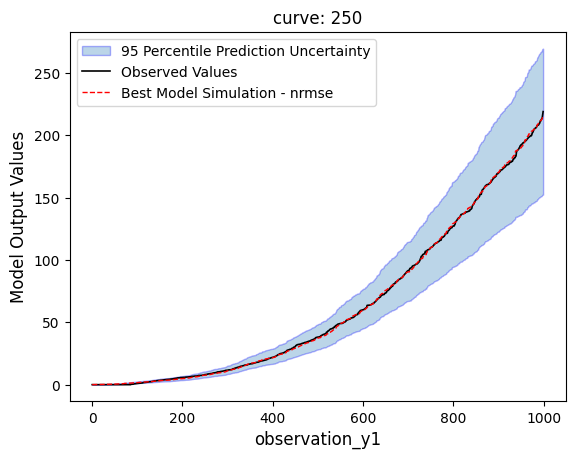

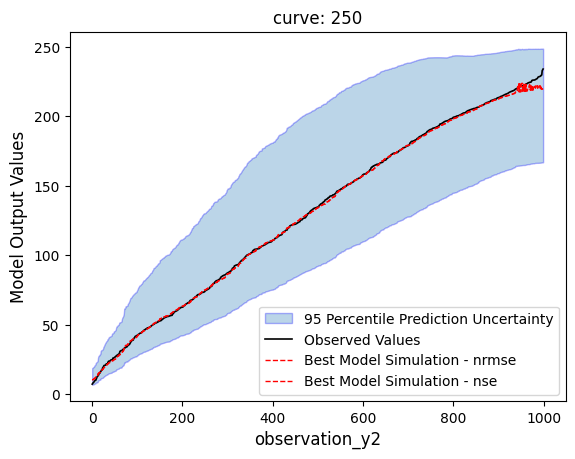

In [62]:
for i in ['y1', 'y2']:
    iter2_ana.plot_ppu(ex_idx, best_sim=True, obs_data=obsdata[i], sort=True, series=i)

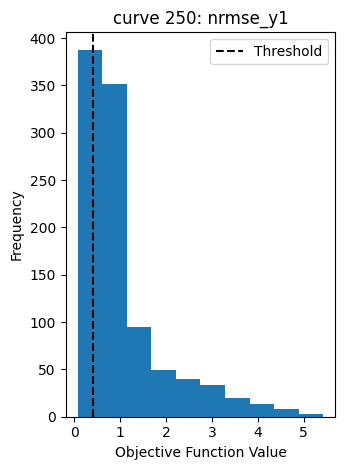

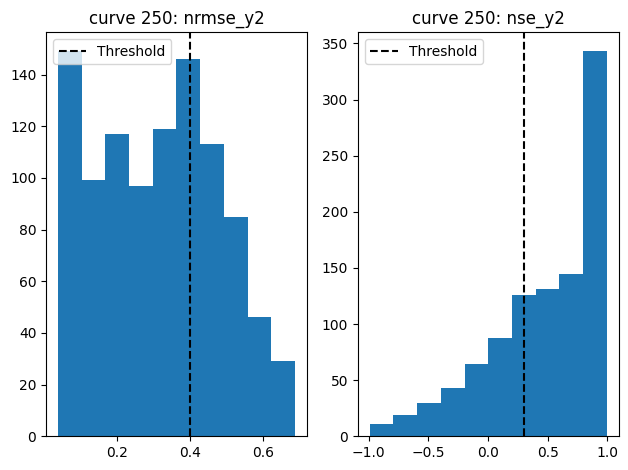

In [63]:
iter2_ana.plot_objective_functions(ex_idx, threshold=True)

nrmse_y1


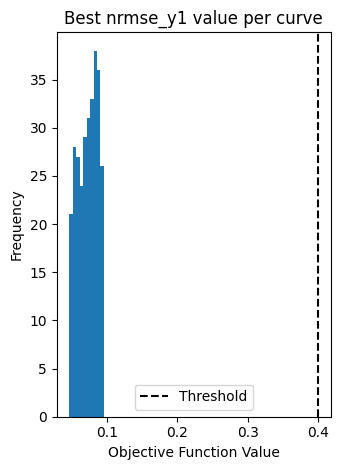

nrmse_y2
nse_y2


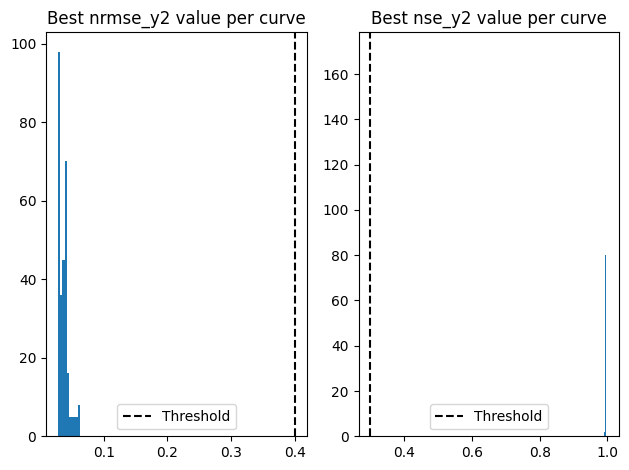

In [64]:
iter2_ana.plot_best_objfuncs(threshold=True)

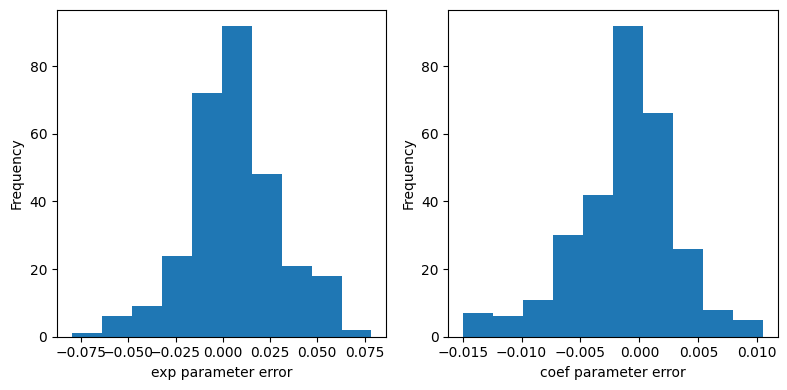

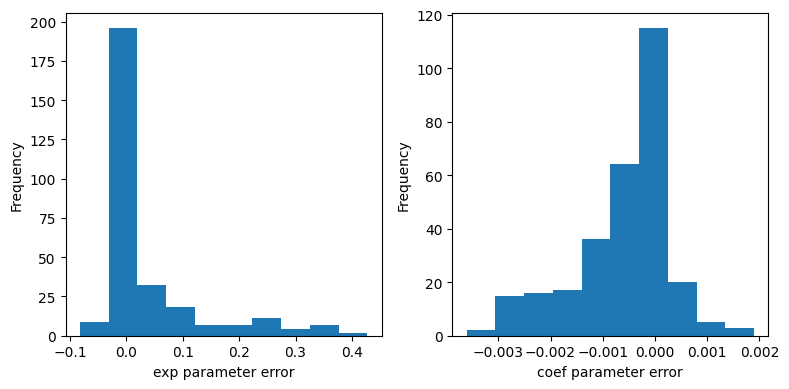

In [65]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].hist(target_exp - iter2_ds.best_parameter_set_y1.sel(objective_functions='nrmse', parameters='exp').values)
axs[0].set_ylabel("Frequency")
axs[0].set_xlabel("exp parameter error")
axs[1].hist(target_coef - iter2_ds.best_parameter_set_y1.sel(objective_functions='nrmse', parameters='coef').values)
axs[1].set_ylabel("Frequency")
axs[1].set_xlabel("coef parameter error")
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].hist(target_exp - iter2_ds.best_parameter_set_y2.sel(objective_functions='nrmse', parameters='exp').values)
axs[0].set_ylabel("Frequency")
axs[0].set_xlabel("exp parameter error")
axs[1].hist(target_coef - iter2_ds.best_parameter_set_y2.sel(objective_functions='nrmse', parameters='coef').values)
axs[1].set_ylabel("Frequency")
axs[1].set_xlabel("coef parameter error")
plt.tight_layout()
plt.show()

Great, it looks like all diagnostic metrics improved. Now, using a probablistic approach like MSCUA is different than an optimization algorthim because we have to use our best judgement and statistical tests to decide when it has "converged." These results look pretty good, we've significantly lowered our 95PPU bounds, better NRMSE distributions, and parameter error with the true values have much narrower distributions around 0.0. Given that I added noise into the theoretical example, we will never be able to truly replicate the original parameter values for ALL models (especially because noise was scaled based on parameter values). SO, you could argue that we are done, but let's see what happens with a 3rd iteration because...we can!!

## Calibration Iteration 3

In [66]:
class MscuaSetupIter3:
    # Define parameters here (before __init__) as variables
    coef = spotpy.parameter.List('coef', iter2_ds.coef_refined.values)
    exp = spotpy.parameter.List('exp', iter2_ds.exp_refined.values)

    def __init__(self, objective_funcs, dbase: Optional[Union[str, Path, MultiDimDb]] = None):
        self.parameter_dimension = num_models
        self.param_dim_names = 'curve'
        self.indata = mdindata
        self.observation_data = obsdata
        
        self.objfuncs = objective_funcs
   
    def simulation(self, paramdict):
        modout = exp_model(self.indata, **paramdict)

        return modout
        
    def evaluation(self):
        return self.observation_data

    def objectivefunction(self, observation, simulation):
        results = {}
        for ts in tqdm.tqdm(self.objfuncs.keys(), desc="Calculating Objective Functions", leave=False):
            results[ts] = {}
            if isinstance(self.objfuncs[ts], list):
                for o in self.objfuncs[ts]:
                    r = o(observation=observation[ts], simulation=simulation[ts], return_dict=True, axis=1)
                    results[ts].update(r)
            else:
                o = self.objfuncs[ts]
                r = o(observation=observation[ts], simulation=simulation[ts], return_dict=True, axis=1)
                results[ts].update(r)

        return results

In [67]:
iter3_setup = MscuaSetupIter3({'y1': nrmse_md, 'y2': [nrmse_md, nse_md]})
iter3_sampler = MsCua(iter3_setup)

In Memory database initialized...


For this 3rd one, let's get crazy and half the objective function threshold.

In [68]:
iter3_results = iter3_sampler.sample(1000, {'y1': {'nrmse': 0.2}, 'y2': {'nrmse': 0.2, 'nse': 0.8}}, 
                                     use_distribution=False)

C:\Users\CND571\PycharmProjects\calmd\src\calmd\utils.py:46: RuntimeWarning: All-NaN slice encountered
  attrobj.maxbound = np.nanmax(attrobj.values, axis=0)
C:\Users\CND571\PycharmProjects\calmd\src\calmd\utils.py:47: RuntimeWarning: All-NaN slice encountered
  attrobj.minbound = np.nanmin(attrobj.values, axis=0)


Sampling 1000 repetitions of the coef parameter...


Sampling 1000 repetitions of the exp parameter...


Running model for 1000 repetitions in database...


Evaluating Objective Function Values...


Calculating Objective Functions:   0%|          | 0/2 [00:00<?, ?it/s]C:\Users\CND571\PycharmProjects\calmd\src\calmd\obj_funcs.py:14: RuntimeWarning: Mean of empty slice
  mse = np.nanmean((observation - simulation) ** 2, axis=axis)


Max number of refined parameter sets: 264
Min number of refined parameter sets: 0

y1
  Calculating the 95PPU...


c:\Users\CND571\.conda\envs\swim1\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


  Calculating p- and r-factor metrics...
  Max p-factor = 0.923
  Min p-factor = 0.0
  Min r-factor = 0.14604116799396955
  Max r-factor = 0.5508985373205891

y2
  Calculating the 95PPU...
  Calculating p- and r-factor metrics...
  Max p-factor = 0.984
  Min p-factor = 0.0
  Min r-factor = 0.2926721082629809
  Max r-factor = 0.761739082856332

7 models had fewer than the minimum allowable refined parameter sets: 25. Either increase the number of samples or exclude these models.
Returning array of failed model indexes.
7 models had a p-factor lower than the allowable minimum: 0.35. Returning array of failed indexes.


Again, successful run, let's look at the diagnostics...

In [70]:
iter3_ds = iter3_sampler.database.to_xarray_dict()
iter3_ana = MsCuaAnalyzerDict(iter3_ds)

The 3rd iteration really did not alter our example parameter distributions all that much.

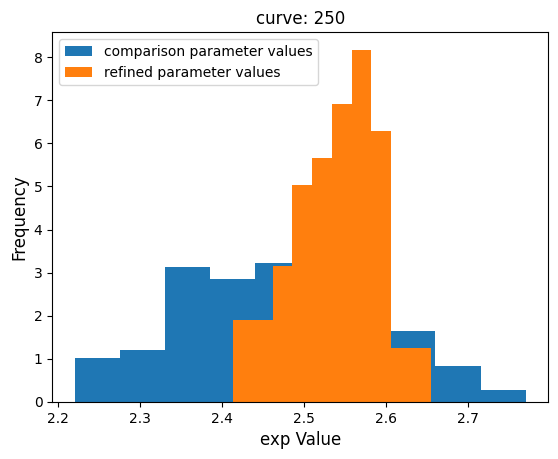

In [74]:
iter3_ana.compare_parameter_distributions('exp', comp_dstb=iter2_ds.exp_refined.values[:,ex_idx], indx=ex_idx, density=True)

Our refined parameter sets look to be mellowing out, and our best simulation is just bouncing around that range (suggests we are now within the "noise" envelope for our target parameter).

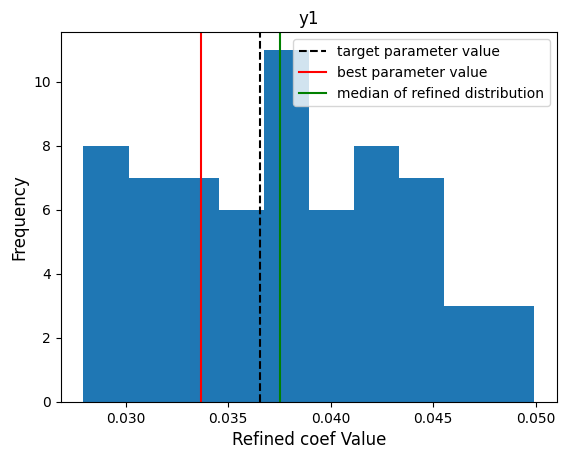

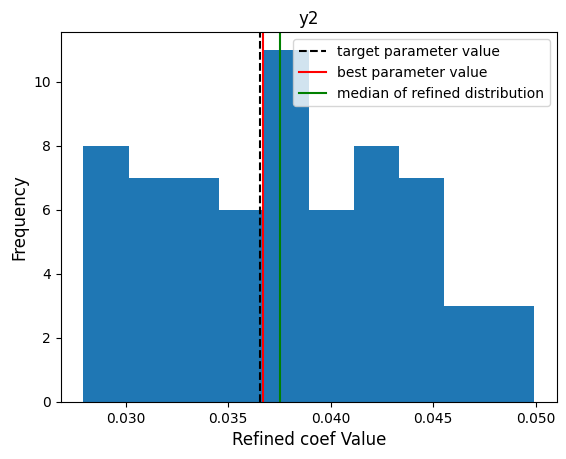

In [78]:
ax = plt.axes()
ax.set_title('y1')
ax.axvline(target_coef[ex_idx], color='black', ls='--', label='target parameter value')
ax.axvline(iter3_ds.best_parameter_set_y1.sel(objective_functions='nrmse', parameters='coef', curve=ex_idx+1).values, color='red', label='best parameter value')
ax.axvline(np.nanmedian(iter3_ds.coef_refined.values[:,ex_idx]), color='green', label='median of refined distribution')
ax.legend()
iter3_ana.plot_refined_parameters('coef', ex_idx, ax=ax)

ax = plt.axes()
ax.set_title('y2')
ax.axvline(target_coef[ex_idx], color='black', ls='--', label='target parameter value')
ax.axvline(iter3_ds.best_parameter_set_y2.sel(objective_functions='nrmse', parameters='coef', curve=ex_idx+1).values, color='red', label='best parameter value')
ax.axvline(np.nanmedian(iter3_ds.coef_refined.values[:,ex_idx]), color='green', label='median of refined distribution')
ax.legend()
iter3_ana.plot_refined_parameters('coef', ex_idx, ax=ax)

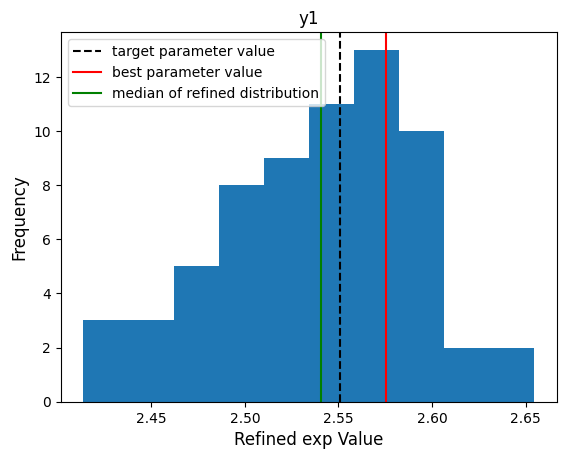

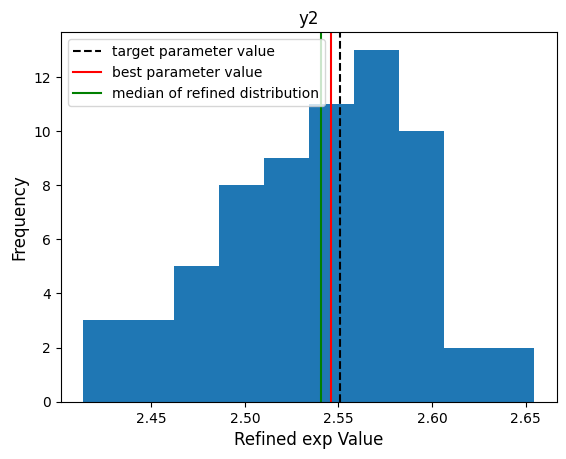

In [81]:
ax = plt.axes()
ax.set_title('y1')
ax.axvline(target_exp[ex_idx], color='black', ls='--', label='target parameter value')
ax.axvline(iter3_ds.best_parameter_set_y1.sel(objective_functions='nrmse', parameters='exp', curve=ex_idx+1).values, color='red', label='best parameter value')
ax.axvline(np.nanmedian(iter3_ds.exp_refined.values[:,ex_idx]), color='green', label='median of refined distribution')
ax.legend()
iter3_ana.plot_refined_parameters('exp', ex_idx, ax=ax)

ax = plt.axes()
ax.set_title('y2')
ax.axvline(target_exp[ex_idx], color='black', ls='--', label='target parameter value')
ax.axvline(iter3_ds.best_parameter_set_y2.sel(objective_functions='nrmse', parameters='exp', curve=ex_idx+1).values, color='red', label='best parameter value')
ax.axvline(np.nanmedian(iter3_ds.exp_refined.values[:,ex_idx]), color='green', label='median of refined distribution')
ax.legend()
iter3_ana.plot_refined_parameters('exp', ex_idx, ax=ax)

One thing that did change, is our 95PPU bounds, they've gotten much tighter.

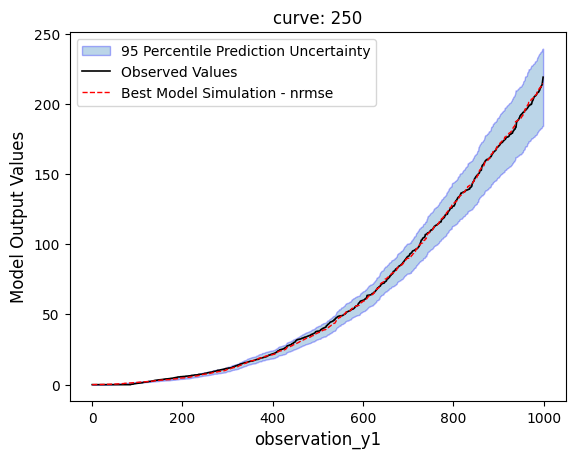

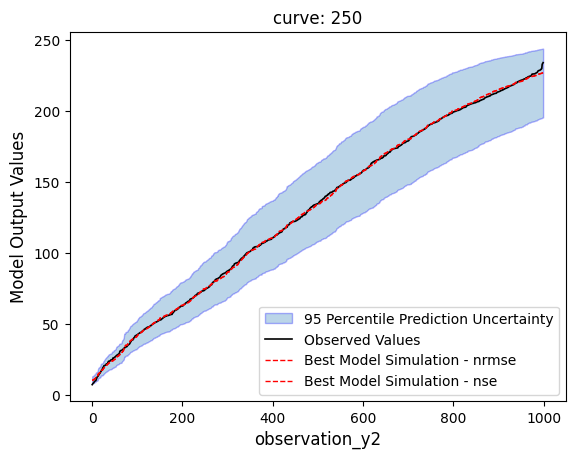

In [83]:
for i in ['y1', 'y2']:
    iter3_ana.plot_ppu(ex_idx, best_sim=True, obs_data=obsdata[i], sort=True, series=i)

For our example model, the distribution of NRMSE values really didn't change.

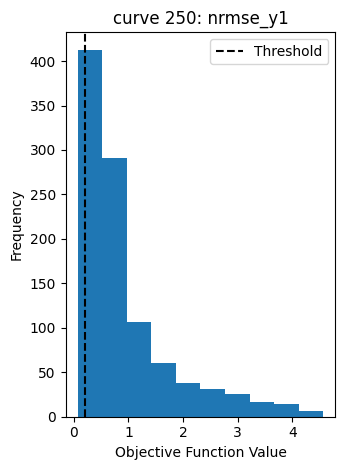

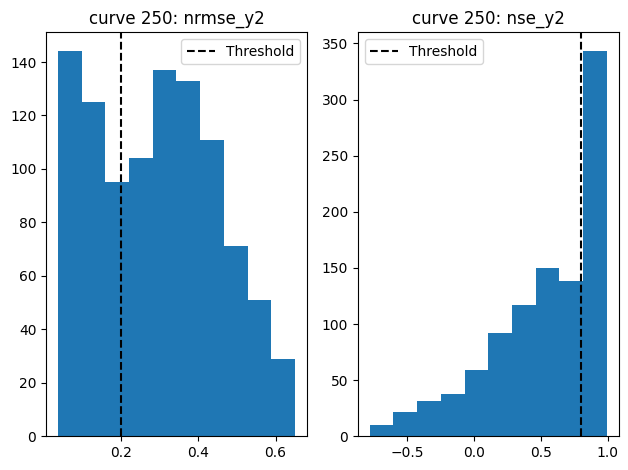

In [84]:
iter3_ana.plot_objective_functions(ex_idx, threshold=True)

Similarily, our BEST objective function values across all models may have improved slightly, but not by much.

nrmse_y1


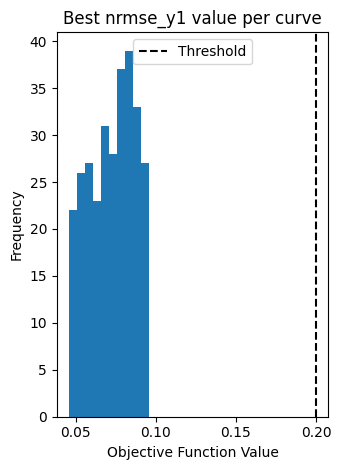

nrmse_y2
nse_y2


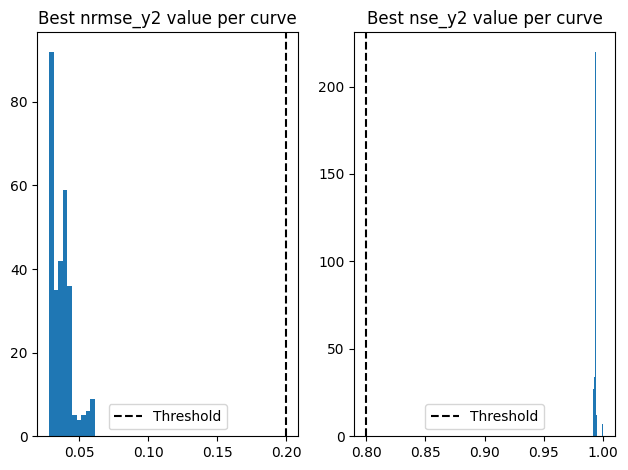

In [85]:
iter3_ana.plot_best_objfuncs(threshold=True)

Comparing to the actual parameter values, we see not much improvement either (again, we're solidly now bouncing around the "noise" envelope).

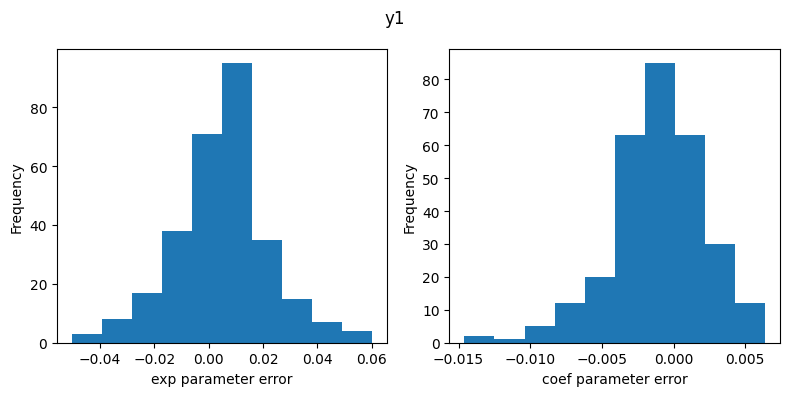

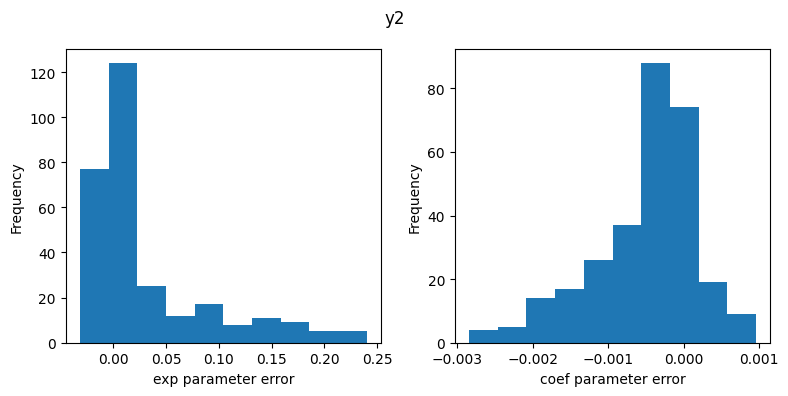

In [87]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
plt.suptitle("y1")
axs[0].hist(target_exp - iter3_ds.best_parameter_set_y1.sel(objective_functions='nrmse', parameters='exp').values)
axs[0].set_ylabel("Frequency")
axs[0].set_xlabel("exp parameter error")
axs[1].hist(target_coef - iter3_ds.best_parameter_set_y1.sel(objective_functions='nrmse', parameters='coef').values)
axs[1].set_ylabel("Frequency")
axs[1].set_xlabel("coef parameter error")
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
plt.suptitle("y2")
axs[0].hist(target_exp - iter3_ds.best_parameter_set_y2.sel(objective_functions='nrmse', parameters='exp').values)
axs[0].set_ylabel("Frequency")
axs[0].set_xlabel("exp parameter error")
axs[1].hist(target_coef - iter3_ds.best_parameter_set_y2.sel(objective_functions='nrmse', parameters='coef').values)
axs[1].set_ylabel("Frequency")
axs[1].set_xlabel("coef parameter error")
plt.tight_layout()
plt.show()

One other check we can do again is the Wasserstein Distance. Remember we calculated this from iteration 1 to see how much the initial distributions changed.

In [88]:
exp_chng = []
coef_chng = []
for i in success:
    exp_dist = iter3_ana.calc_param_distribution_change('exp', comp_dstb=iter2_ds.exp_samples.values[:,i], indx=i)
    coef_dist = iter3_ana.calc_param_distribution_change('coef', comp_dstb=iter2_ds.coef_samples.values[:,i], indx=i)
    exp_chng.append(exp_dist)
    coef_chng.append(coef_dist)
exp_wd = np.array(exp_chng)
coef_wd = np.array(coef_chng)

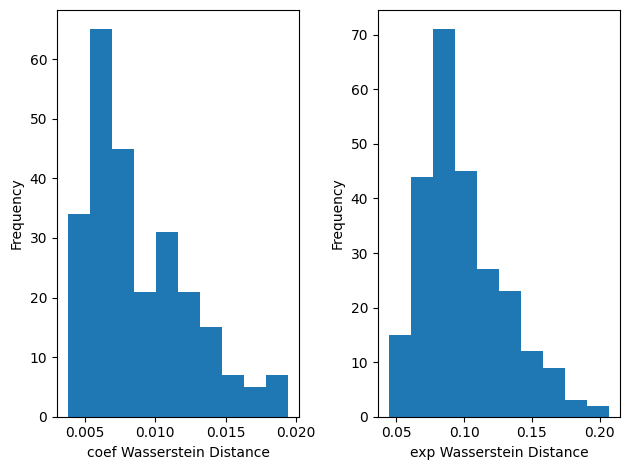

In [89]:
fig, axs = plt.subplots(1, 2)
axs[0].hist(coef_wd)
axs[1].hist(exp_wd)
axs[0].set_xlabel("coef Wasserstein Distance")
axs[1].set_xlabel("exp Wasserstein Distance")
axs[0].set_ylabel("Frequency")
axs[1].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

This is a pretty telling check, we've pretty drastically changed these distributions meaning our parameter distributions are not really changing in the 3rd iteration. Remember we have max Wasserstein Distance for the "exp" parameter that were over 1.0, now they seem to have normalized around 0.01 and 0.1.

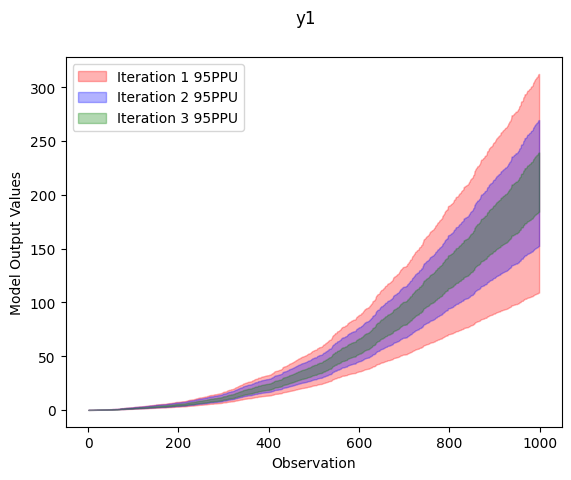

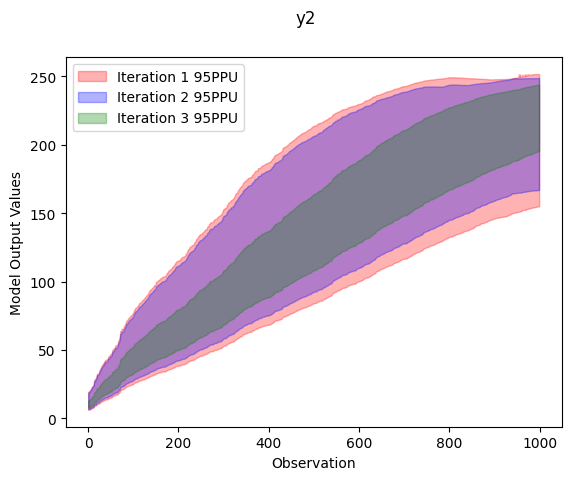

In [91]:
for i in ['y1', 'y2']:
    indx = ex_idx
    i1_srt_idx = np.argsort(cal_ds[f"95PPU_lower_{i}"].values[:,indx])
    i2_srt_idx = np.argsort(iter2_ds[f"95PPU_lower_{i}"].values[:,indx])
    i3_srt_idx = np.argsort(iter3_ds[f"95PPU_lower_{i}"].values[:,indx])
    ax = plt.axes()
    plt.suptitle(i)
    ax.fill_between(np.arange(cal_ds[f"95PPU_lower_{i}"].values.shape[0]), 
                                cal_ds[f"95PPU_upper_{i}"].values[i1_srt_idx,indx], 
                                cal_ds[f"95PPU_lower_{i}"].values[i1_srt_idx,indx], 
                                label="Iteration 1 95PPU",
                                ec='red',
                                facecolor='red',
                                alpha=0.3)
    ax.fill_between(np.arange(iter2_ds[f"95PPU_lower_{i}"].values.shape[0]), 
                                iter2_ds[f"95PPU_upper_{i}"].values[i2_srt_idx,indx], 
                                iter2_ds[f"95PPU_lower_{i}"].values[i2_srt_idx,indx], 
                                label="Iteration 2 95PPU",
                                ec='blue',
                                facecolor='blue',
                                alpha=0.3)
    ax.fill_between(np.arange(iter3_ds[f"95PPU_lower_{i}"].values.shape[0]), 
                                iter3_ds[f"95PPU_upper_{i}"].values[i3_srt_idx,indx], 
                                iter3_ds[f"95PPU_lower_{i}"].values[i3_srt_idx,indx], 
                                label="Iteration 3 95PPU",
                                ec='green',
                                facecolor='green',
                                alpha=0.3)
    ax.set_ylabel('Model Output Values')
    ax.set_xlabel('Observation')
    ax.legend()
    plt.show()

So, the main benefit to adding a 3rd iteration was to reduce the calibrated model uncertainty. The "best" simulations did not really change much from iteration to iteration but the 95PPU got smaller and smaller, which we would expect as we make our objective function threshold more stringent. The above plot shows the decrease of the 95PPU with each iteration.